In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.qt import qt
from multicam_tng.utils import generate_randoms, match_bar_dmo, get_an_from_mpeak_mah
from scipy.stats import spearmanr
from multicam.multicam import MultiCAM


from astropy.table import Table

from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


# Load Data

In [2]:
TNG_H = 0.6774
COLOR_CUT = 1.0

In [3]:
# this ist just metadata which sims share so it's ok to use TNG300

metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [4]:
# load data and only use subhaleos with valid flag
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [5]:
dmo_raw = Table.read("../../data/dmo_final.ecsv")
dmo_raw["z12"] = (1 / dmo_raw["a12"]) - 1  # need for CAM
len(dmo_raw)

15890

In [6]:
# we again (mostly) avoid resolution effects on hydro catalog by applying an mpeak cut
# Specifically, we dan't want to use any unresolved galaxies in the hydro for constructing the SHAM SHMR!
log_mpeak_hydro = np.log10(hydro_raw["mpeak"])
_mask = log_mpeak_hydro > 11
hydro_high = hydro_raw[_mask]
len(hydro_high)

12652

In [7]:
# now we pick the top len(hydro_high) most massive DMO haloes with mpeak
assert len(dmo_raw) > len(hydro_high)
_x = np.log10(dmo_raw["mpeak"].data)
x = log10_mpeak_sham = np.sort(_x)[-len(hydro_high) :]
x_raw = np.log10(dmo_raw["mpeak"])
dmo_high = dmo_raw[x_raw >= x.min()]
len(dmo_high)

12652

# SHAM

In [8]:
# get sham prediction for stellar mass
x = log10_mpeak_sham = np.log10(dmo_high["mpeak"])
y = log10_stellar_mass_sham = np.log10(hydro_high["stellar_mass"].data)


print(len(y), len(x))
assert len(x) == len(y)  # pre-requisite for applying SHAM

# SHAM mean relation (NO scatter), also defines SHMR
logmstar_sham = qt(x, y)

12652 12652


(array([   0.,    0.,    0.,    0.,    2.,    0.,    2.,    8.,    6.,
           9.,   14.,   38.,   92.,  295.,  729., 1282., 1782., 1838.,
        1515., 1400., 1039., 1006.,  753.,  413.,  206.,  106.,   61.,
          29.,   20.,    5.,    2.]),
 array([ 5.56381989,  5.77835512,  5.99288988,  6.20742512,  6.42195988,
         6.63649511,  6.85102987,  7.06556511,  7.28009987,  7.49463511,
         7.70917034,  7.9237051 ,  8.13823986,  8.35277557,  8.56731033,
         8.78184509,  8.99637985,  9.21091461,  9.42545033,  9.63998508,
         9.8545208 , 10.06905556, 10.28359032, 10.49812508, 10.71265984,
        10.9271946 , 11.14173031, 11.35626507, 11.57080078, 11.78533554,
        11.9998703 , 12.21440506]),
 [<matplotlib.patches.Polygon at 0x12312f620>])

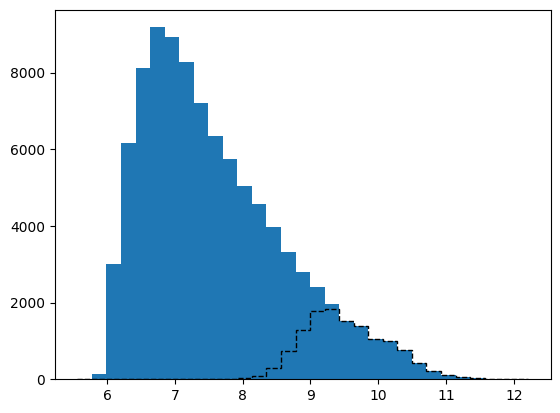

In [9]:
# sham distribution matches highest stellar mass distribution exactly

x = np.log10(hydro_raw["stellar_mass"].data)
mask = x > 0


_, bins, _ = plt.hist(x[mask], bins=31)
plt.hist(logmstar_sham, bins=bins, histtype="step", ls="--", color="k")

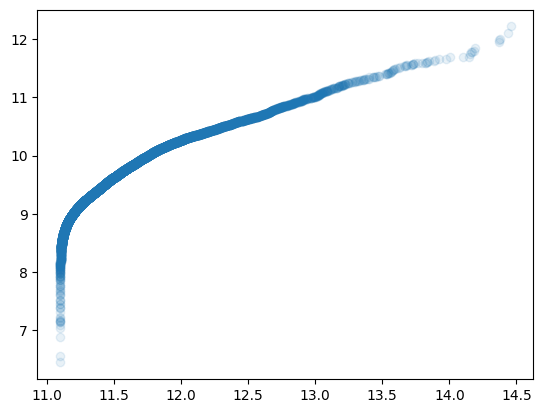

In [10]:
# what does the SHMR look like
plt.scatter(log10_mpeak_sham, logmstar_sham, alpha=0.1)

# TODO: Add the matched one if we want an actual comparison

In [11]:
x = np.log10(hydro_high["stellar_mass"].data)
star_mask = (x > 9.5) & (x < 10.2)
hydro_mstar_cut = hydro_high[star_mask]

sham_mask = (logmstar_sham > 9.5) & (logmstar_sham < 10.2)
dmo_sham = dmo_high[sham_mask]  # dmo_raw already has cut on mpeak > 11


len(hydro_mstar_cut), len(dmo_sham)


(4050, 4050)

In [12]:
# CAM prediction for color
color_cam_pred = qt(dmo_sham["z12"].data, hydro_mstar_cut["color"])
color_cam_pred.shape

(4050,)

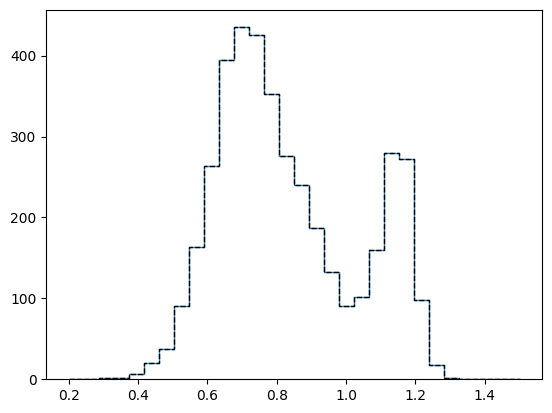

In [13]:
# shoudl be exactly the same
bins = np.linspace(0.2, 1.5, 31)
plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step")
plt.hist(color_cam_pred, bins=bins, histtype="step", linestyle="--", color="k");

## Clustering (CAM)

In [14]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)
randoms.shape

(50000, 3)

In [15]:
red_pred = dmo_sham[color_cam_pred > COLOR_CUT]
blue_pred = dmo_sham[color_cam_pred <= COLOR_CUT]

true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


In [16]:
len(red_pred), len(red_true), len(blue_pred), len(blue_true)

(981, 981, 3069, 3069)

In [17]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [18]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


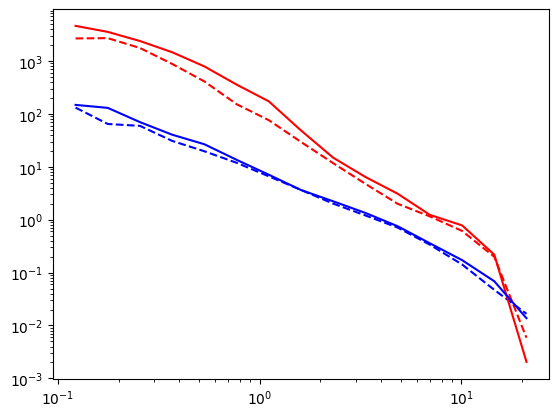

In [19]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

(0.2, 2.0)

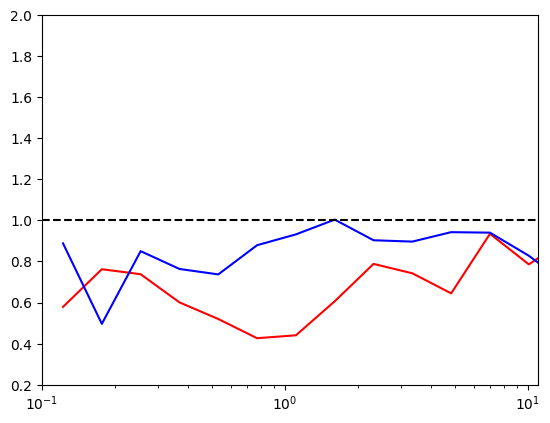

In [20]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

# MultiCAM

In [21]:
# matched dmo and hydro on mpeak mass bin for MultiCAM training.
# only need it where we actually have SHAM prediction (high)
dmo_high["logmstar_sham"] = logmstar_sham
matched_dmo, matched_bar = match_bar_dmo(dmo_table=dmo_high, bar_table=hydro_high)
len(matched_dmo), len(matched_bar)

(8212, 8212)

In [22]:
ns = np.linspace(0, 1, 21)[1:-1]  # want to avoid 0, 1 edge cases


In [23]:
# want to train multicam on matched catalog within the mpeak mass bin
m1 = np.log10(matched_dmo["mpeak"])
_mask = (m1 > 11) & (m1 < 12)

matched_binned_dmo = matched_dmo[_mask]
matched_binned_bar = matched_bar[_mask]

# get deviation from SHAM
matched_binned_bar["star_dev"] = (
    np.log10(matched_binned_bar["stellar_mass"]) - matched_binned_dmo["logmstar_sham"]
)

len(matched_binned_dmo), len(matched_binned_bar)

(7248, 7248)

In [24]:
x_train = get_an_from_mpeak_mah(matched_binned_dmo["mpeak_mah"], scales=scales, ns=ns)
y_train = np.stack(
    [matched_binned_bar["color"], matched_binned_bar["star_dev"]], axis=-1
)

x_train.shape, y_train.shape


((7248, 19), (7248, 2))

In [25]:
# want to apply multicam on DMO mpeak mass bin and get deviaton
# and i guess by 'full' it means only the once where we have SHAM
x = np.log10(dmo_high["mpeak"])
_mask = (x > 11) & (x < 12)
dmo_mpeak_bin = dmo_high[_mask]

x_test = get_an_from_mpeak_mah(dmo_mpeak_bin["mpeak_mah"], scales=scales, ns=ns)
x_test.shape

(10943, 19)

In [30]:
model = MultiCAM(len(ns), 2)
model.fit(x_train, y_train)

y_pred = model.predict(x_test, y_target=y_train)
y_pred.shape

(10943, 19)


(10943, 2)

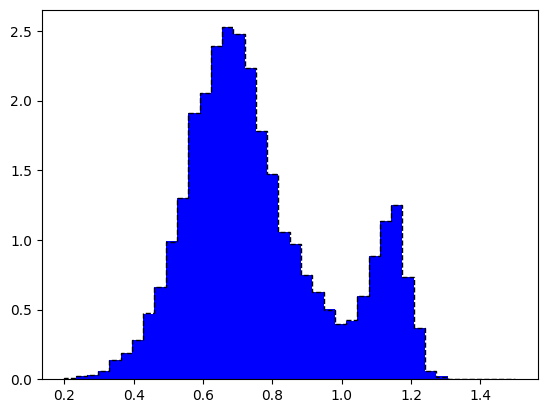

In [37]:
# sanity
bins = np.linspace(0.2, 1.5, 41)

color_true = y_train[:, 0]
color_pred = y_pred[:, 0]

plt.hist(color_true, bins=bins, ls="-", color="b", density=True)
plt.hist(color_pred, bins=bins, histtype="step", ls="--", color="k", density=True);


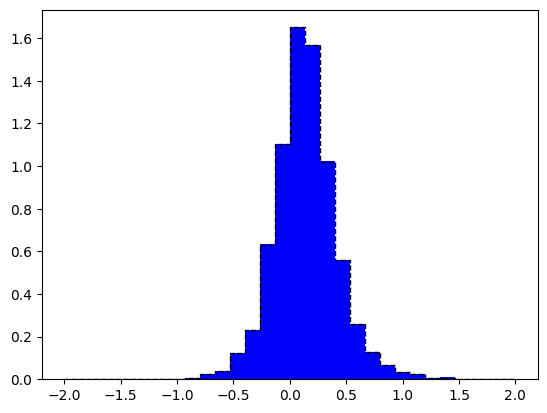

In [ ]:
# sanity
dev_true = y_train[:, 1]
dev_pred = y_pred[:, 1]

bins = np.linspace(-2, 2, 31)
plt.hist(dev_true, bins=bins, ls="-", color="b", density=True)
plt.hist(dev_pred, bins=bins, histtype="step", ls="--", color="k", density=True);


In [33]:
# now use predicted deviation to get new "SHAM" bins for MultiCAM
x = np.log10(dmo_high["mpeak"])
_mask = (x > 11) & (x < 12)

dmo_mpeak_bin = dmo_high[_mask]
log10_pred_stellar_mass = dmo_high["logmstar_sham"][_mask] + y_pred[:, 1]

_mask2 = (log10_pred_stellar_mass > 9.5) & (log10_pred_stellar_mass < 10.2)

# just for comparison
len(dmo_mpeak_bin[_mask2]), len(hydro_mstar_cut)

(4662, 4050)

In [34]:
dmo_multicam = dmo_mpeak_bin[_mask2]
len(dmo_multicam)

4662

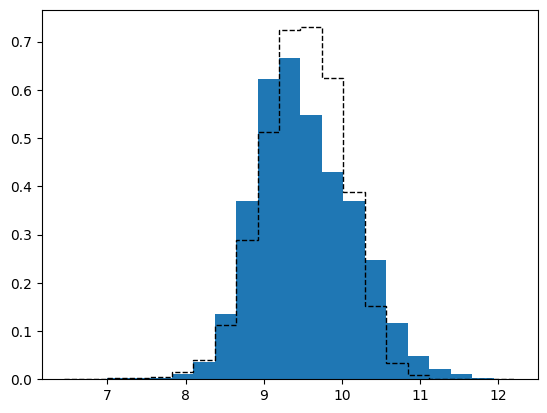

In [36]:
# compare stellar mass distributions in mpeak mass bin
# NOTE: not sure if fully apples-to-apples as hydro high has not mpeak bin cut.

_, bins, _ = plt.hist(np.log10(hydro_high["stellar_mass"]), bins=21, density=True)
plt.hist(
    log10_pred_stellar_mass,
    bins=bins,
    histtype="step",
    color="k",
    ls="--",
    density=True,
);


In [40]:
# now get final predicted color from multicam on this bin
x_test = get_an_from_mpeak_mah(dmo_multicam["mpeak_mah"], scales=scales, ns=ns)
_dummy = np.ones_like(hydro_mstar_cut["color"])
y_true = np.stack(
    [hydro_mstar_cut["color"], _dummy],
    axis=-1,
)

y_multicam = model.predict(x_test, y_target=y_true)
multicam_color_pred = y_multicam[:, 0]
multicam_color_pred.shape

(4662, 19)


(4662,)

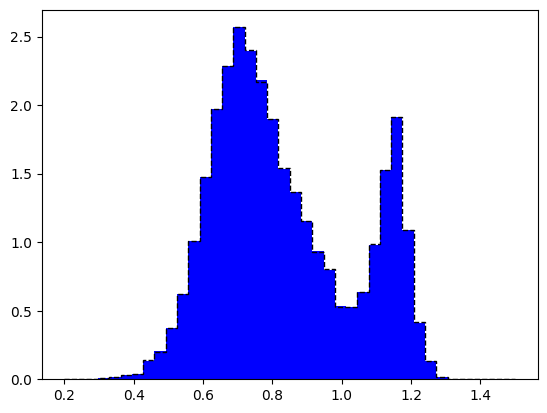

In [42]:
# multicam matches true color distribution exactly (note, need to use 'density=True')
bins = np.linspace(0.2, 1.5, 41)
plt.hist(hydro_mstar_cut["color"], bins=bins, ls="-", color="b", density=True)
plt.hist(
    multicam_color_pred, bins=bins, histtype="step", ls="--", color="k", density=True
);


In [43]:
multicam_red_pred = dmo_multicam[multicam_color_pred > COLOR_CUT]
multicam_blue_pred = dmo_multicam[multicam_color_pred <= COLOR_CUT]

In [45]:
print(len(multicam_red_pred), len(red_true), len(multicam_blue_pred), len(blue_true))


# NOTE: proportion is the same again which is a good sign
print(len(multicam_red_pred) / (len(multicam_red_pred) + len(multicam_blue_pred)))
print(len(red_true) / (len(red_true) + len(blue_true)))


1130 981 3532 3069
0.2423852423852424
0.24222222222222223


In [46]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


(0.001, 10000.0)

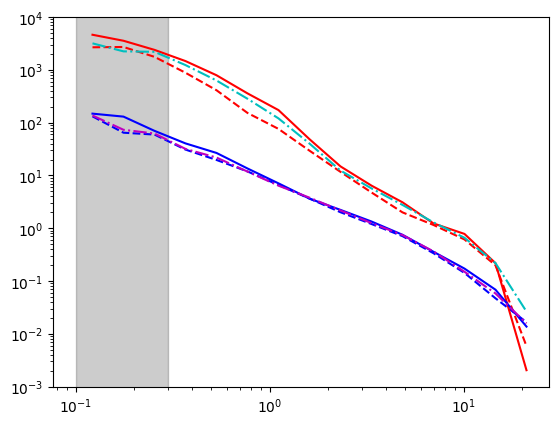

In [47]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

plt.loglog(rbin_centers, xi_red_multicam, c="c", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="m", ls="-.")

plt.fill_betweenx([-2, 1e5], 0.1, 0.3, color="k", alpha=0.2)
plt.ylim(1e-3, 1e4)

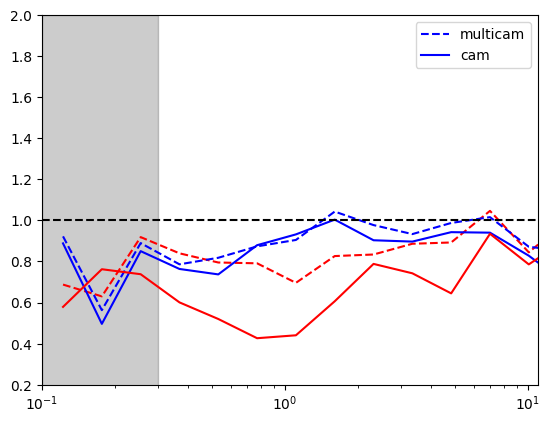

In [48]:
plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# plt.axvline(0.3, c="k")
plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)
# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

In [49]:
# blue improves a little bit, probably insignificantly
# red definitely improves over CAM.

# SHAM comparison

In [50]:
xyz_true = return_xyz_formatted_array(
    hydro_mstar_cut["x"].data, hydro_mstar_cut["y"].data, hydro_mstar_cut["z"].data
)

xyz_sham = return_xyz_formatted_array(
    dmo_sham["x"].data, dmo_sham["y"].data, dmo_sham["z"].data
)

xyz_multicam = return_xyz_formatted_array(
    dmo_multicam["x"].data, dmo_multicam["y"].data, dmo_multicam["z"].data
)


xi_true = tpcf(xyz_true, rbins, randoms=randoms, period=Lbox, num_threads="max")
xi_cam = tpcf(xyz_sham, rbins, randoms=randoms, period=Lbox, num_threads="max")
xi_multicam = tpcf(xyz_multicam, rbins, randoms=randoms, period=Lbox, num_threads="max")


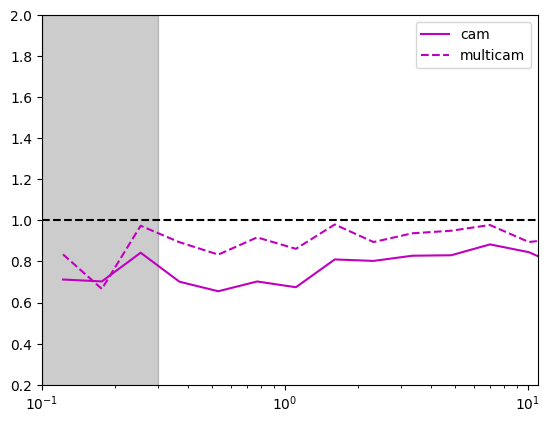

In [51]:
plt.semilogx(rbin_centers, xi_cam / xi_true, c="m", ls="-", label="cam")
plt.semilogx(rbin_centers, xi_multicam / xi_true, c="m", ls="--", label="multicam")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# plt.axvline(0.3, c="k")
plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)
# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output